In [26]:
!pip install -q ultralytics roboflow

In [27]:
import os, shutil
from pathlib import Path
from collections import Counter

import yaml
import torch

if Path("/kaggle/working").exists():
    BASE = Path("/kaggle/working")
elif Path("/content").exists():
    BASE = Path("/content")
else:
    BASE = Path.cwd()

print(f"Base: {BASE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE'}")

Base: /kaggle/working
GPU: Tesla T4


In [ ]:
from roboflow import Roboflow

SRC = BASE / "wound-13"

if not SRC.exists():
    rf = Roboflow(api_key="")
    project = rf.workspace("w-afwxp").project("wound-ebsdw")
    version = project.version(13)
    version.download("yolov8", location=str(SRC))
    print("Downloaded.")
else:
    print("Already exists.")

# Quick count
for split in ["train", "valid", "test"]:
    n = len(list((SRC / split / "images").glob("*")))
    print(f"  {split}: {n} images")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/wound-13 in yolov8:: 100%|██████████| 7230/7230 [00:00<00:00, 7296.96it/s]

Downloaded.
  train: 3159 images
  valid: 300 images
  test: 150 images


In [29]:
DST = BASE / "wound-single"
stats = Counter()

for src_split, dst_split in [("train", "train"), ("valid", "val"), ("test", "test")]:
    src_img = SRC / src_split / "images"
    src_lbl = SRC / src_split / "labels"
    dst_img = DST / dst_split / "images"
    dst_lbl = DST / dst_split / "labels"
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    for lbl_path in sorted(src_lbl.glob("*.txt")):
        lines_out = []
        for line in lbl_path.read_text().strip().split("\n"):
            if not line.strip():
                continue
            parts = line.strip().split()
            cls = int(parts[0])
            if cls == 5:  # no_abnormality — skip
                stats["dropped_no_abnormality"] += 1
                continue
            # remap 0-4 → 0
            lines_out.append(f"0 {' '.join(parts[1:])}")
            stats[f"orig_cls_{cls}"] += 1

        # Write label (even if empty — becomes negative example)
        (dst_lbl / lbl_path.name).write_text("\n".join(lines_out))

        # Symlink image (save disk)
        img_name = lbl_path.stem
        for ext in [".jpg", ".jpeg", ".png"]:
            img_src = src_img / (img_name + ext)
            if img_src.exists():
                img_dst = dst_img / (img_name + ext)
                if not img_dst.exists():
                    shutil.copy2(img_src, img_dst)
                stats[f"{dst_split}_images"] += 1
                break

print("Remapping done:")
for k, v in sorted(stats.items()):
    print(f"  {k}: {v}")

Remapping done:
  dropped_no_abnormality: 802
  orig_cls_0: 950
  orig_cls_1: 229
  orig_cls_2: 996
  orig_cls_3: 1384
  orig_cls_4: 677
  test_images: 150
  train_images: 3159
  val_images: 300


In [30]:
# data.yaml
yaml_path = DST / "data.yaml"
data_yaml = {
    "path": str(DST.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 1,
    "names": ["wound"],
}
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(open(yaml_path).read())

names:
- wound
nc: 1
path: /kaggle/working/wound-single
test: test/images
train: train/images
val: val/images



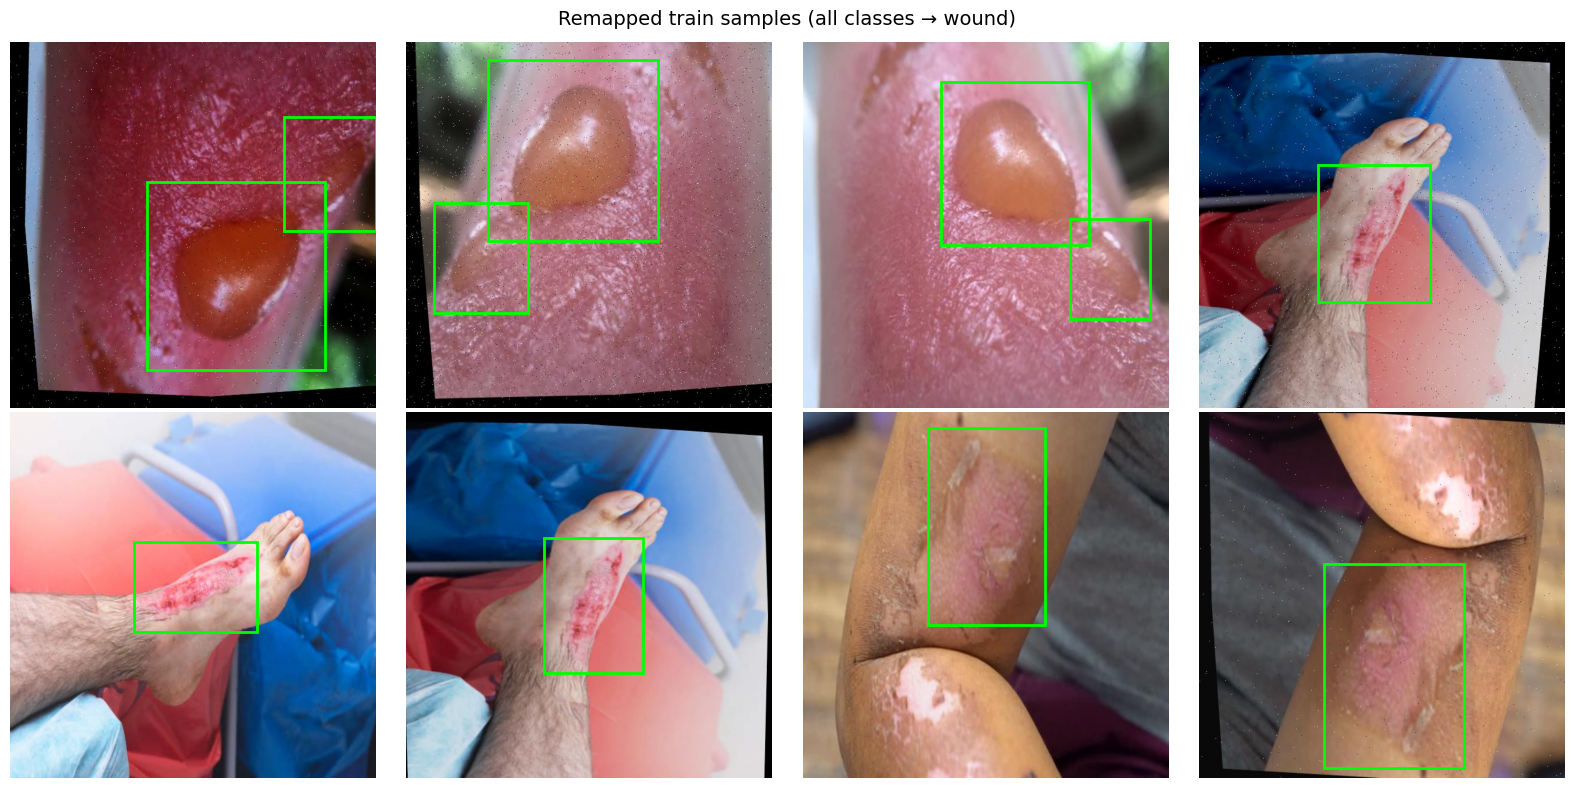

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_dir = DST / "train" / "images"
lbl_dir = DST / "train" / "labels"
imgs = sorted(img_dir.glob("*.jpg"))[:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, p in zip(axes.flat, imgs):
    im = Image.open(p)
    ax.imshow(im)
    w, h = im.size
    lbl = lbl_dir / p.with_suffix(".txt").name
    if lbl.exists():
        for line in lbl.read_text().strip().split("\n"):
            if not line.strip(): continue
            _, xc, yc, bw, bh = map(float, line.split())
            rect = patches.Rectangle(
                ((xc - bw/2)*w, (yc - bh/2)*h), bw*w, bh*h,
                linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
    ax.axis("off")
plt.suptitle("Remapped train samples (all classes → wound)", fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/wound-single/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, per

In [33]:
run_dirs = sorted(Path("runs/detect").glob("train*"), key=os.path.getmtime)
best_pt = run_dirs[-1] / "weights" / "best.pt"
print(f"Best weights: {best_pt} ({best_pt.stat().st_size / 1e6:.1f} MB)")

best_model = YOLO(str(best_pt))
metrics = best_model.val(data=str(yaml_path), verbose=True)

print(f"\n{'='*40}")
print(f"mAP@0.5:      {metrics.box.map50:.4f}  (target: >= 0.85)")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision:     {metrics.box.mp:.4f}")
print(f"Recall:        {metrics.box.mr:.4f}  (target: >= 0.90)")
print(f"{'='*40}")

Best weights: runs/detect/train2/weights/best.pt (6.2 MB)
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 652.3±335.7 MB/s, size: 38.5 KB)
val: Scanning /kaggle/working/wound-single/val/labels.cache... 300 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 83.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.2it/s 3.7s0.1s
                   all        300        372       0.77      0.718      0.779      0.424
Speed: 1.8ms preprocess, 4.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2

mAP@0.5:      0.7787  (target: >= 0.85)
mAP@0.5:0.95: 0.4239
Precision:     0.7696
Recall:        0.7181  (target: >= 0.90)


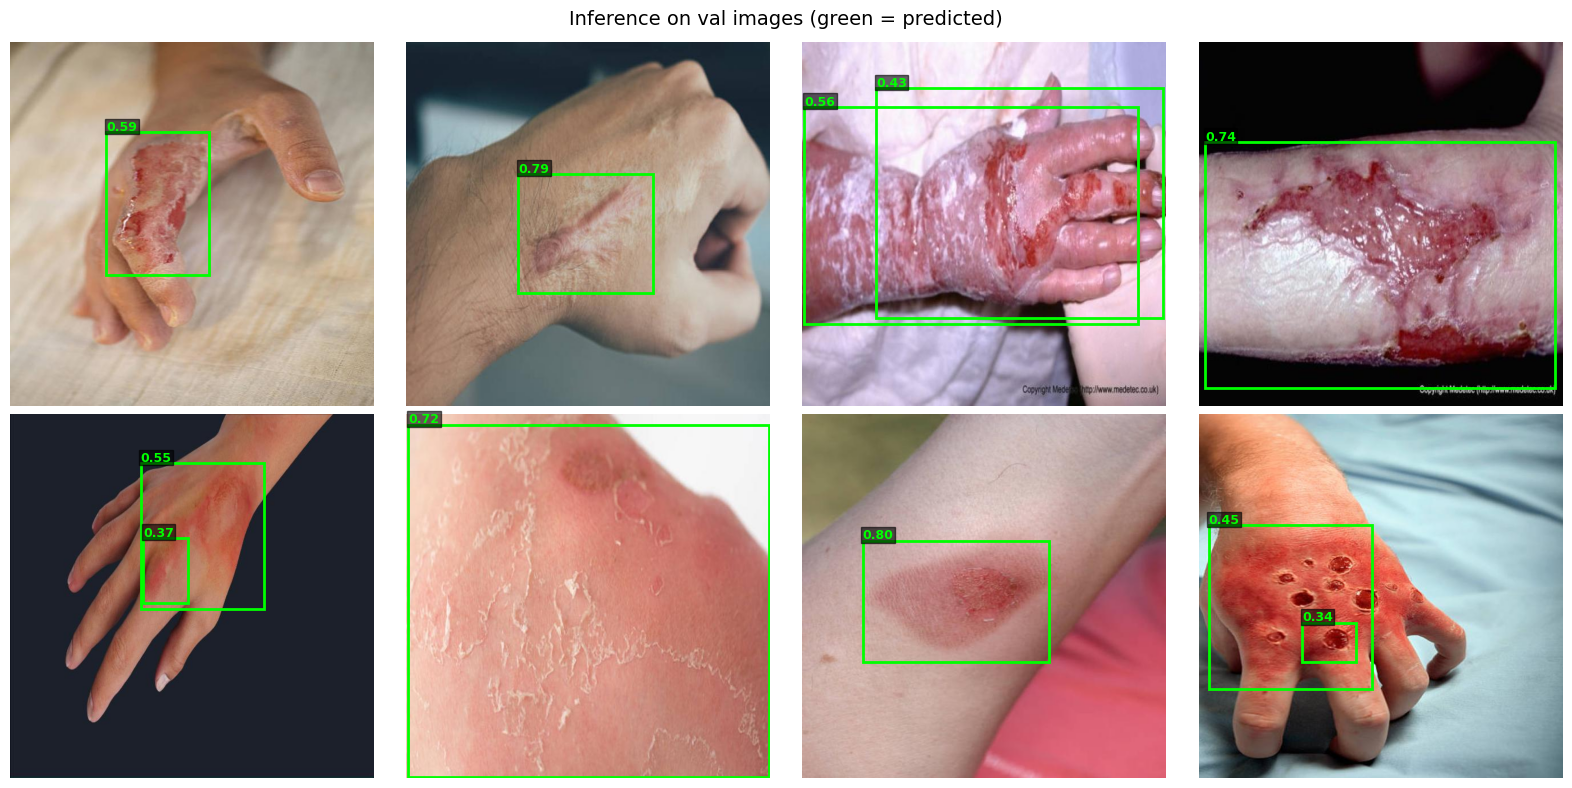

In [34]:
val_imgs = sorted((DST / "val" / "images").glob("*.jpg"))
test_imgs = []
for p in val_imgs:
    lbl = DST / "val" / "labels" / p.with_suffix(".txt").name
    if lbl.exists() and lbl.read_text().strip():
        test_imgs.append(p)
    if len(test_imgs) == 8:
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img_path in zip(axes.flat, test_imgs):
    res = best_model(str(img_path), verbose=False)
    im = Image.open(img_path)
    ax.imshow(im)
    w, h = im.size
    for r in res:
        for box in r.boxes:
            c = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            rect = patches.Rectangle(
                (c[0], c[1]), c[2]-c[0], c[3]-c[1],
                linewidth=2, edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(c[0], c[1]-4, f"{conf:.2f}", color="lime", fontsize=9,
                    fontweight="bold", bbox=dict(facecolor="black", alpha=0.6, pad=1))
    ax.axis("off")
plt.suptitle("Inference on val images (green = predicted)", fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
export_path = BASE / "wound_yolov8n_best.pt"
shutil.copy2(best_pt, export_path)
print(f"Exported: {export_path} ({export_path.stat().st_size / 1e6:.1f} MB)")
print("Download this file and place in backend/ for deployment.")

Exported: /kaggle/working/wound_yolov8n_best.pt (6.2 MB)
Download this file and place in backend/ for deployment.
